In [1]:
#Baseline Algorithms, Function Implementations
from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
import numpy as np
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv()
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()

<class 'type'>
obs: [0.8  0.5  0.   0.3  0.4  0.9  0.2  0.7  0.8  0.5  0.61 0.  ]
dtype: float32
shape: (12,)
obs: [0.7  0.1  0.2  0.2  0.2  0.8  0.9  0.3  0.8  0.9  0.07 0.  ]
dtype: float32
shape: (12,)
obs: [0.2  0.8  0.2  0.7  0.6  0.9  0.2  0.8  0.5  0.2  0.53 0.  ]
dtype: float32
shape: (12,)
obs: [0.7  0.1  0.2  0.2  0.2  0.8  0.9  0.3  0.8  0.9  0.07 0.  ]
dtype: float32
shape: (12,)
obs: [0.2  0.8  0.2  0.7  0.6  0.9  0.2  0.8  0.5  0.2  0.53 0.  ]
dtype: float32
shape: (12,)
obs: [0.5  0.4  0.1  0.8  1.   0.1  0.3  0.8  0.4  1.   0.29 0.  ]
dtype: float32
shape: (12,)
obs: [0.6  0.5  0.3  0.2  0.5  0.3  0.8  0.4  0.2  0.8  0.27 0.  ]
dtype: float32
shape: (12,)
obs: [0.7  0.3  0.   0.9  0.6  0.5  0.5  0.4  0.5  0.6  0.85 0.  ]
dtype: float32
shape: (12,)
obs: [0.7  0.1  0.2  0.2  0.2  0.8  0.9  0.3  0.8  0.9  0.07 0.  ]
dtype: float32
shape: (12,)
obs: [0.7  0.1  0.2  0.2  0.2  0.8  0.9  0.3  0.8  0.9  0.07 0.  ]
dtype: float32
shape: (12,)
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


In [2]:
#Here we implement Baseline CGR as a function that can be called 
def BaselineCGR(env,seed):
    
    init_observation,init_info=env.reset(seed)
    #print(init_observation)
    delivery_ratio_metric=None
    contact_energy_efficiency=None
    total_reward=0
    done=False
    while not done:
        action = 1
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()

    

In [5]:

def AdaptiveSorting(env,seed):
    initial_observation,initial_information=env.reset(seed)
    print(initial_observation)
    initial_data_volume=initial_observation[10]*100
    contacts_available=initial_observation[0:10]
    sorted_matrix=np.zeros([10,2])
    current_contact_iterator=0
    total_reward=0
  
    
    #Next we must calculate the initial allocation of contacts
    j=0
    for i in contacts_available:
        sorted_matrix[j,0]=i
        sorted_matrix[j,1]=j
        j=j+1
    sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
    #print("Initial Sorted Matrix")
    #print(sorted_matrix)
    remaining_data=initial_data_volume
    #print("Initial Data to send")
    #print(remaining_data)
    decision_matrix=np.zeros([10,2])
    
    j=0
    for i in range(0,len(decision_matrix)):
        if (remaining_data>0):
            if sorted_matrix[i,0]<1:
                remaining_data=remaining_data-(10-sorted_matrix[i,0]*10)
                
                decision_matrix[i,0]=1
                decision_matrix[i,1]=sorted_matrix[i,1]
            else:
                decision_matrix[i,0]=0
                decision_matrix[i,1]=sorted_matrix[i,1]
        else:
            decision_matrix[i,0]=0
            decision_matrix[i,1]=sorted_matrix[i,1]
    #Next we must reorder the decision matrix
    
    done=False
    #print("Decision Matrix")
    #print(decision_matrix)
    sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
    #print("Sorted Decisions")
    #print(sorted_decisions)
    action_decision_matrix=np.zeros(10)
    for i in range(0,len(sorted_decisions)):
        action_decision_matrix[i]=sorted_decisions[i,0]
    #print("Actual set of Actions")
    #print(action_decision_matrix)
    obs=initial_observation
    i=0
    while not done:
        #print(i)
        #print("Next Decision")
        #print(action_decision_matrix[i])
        if action_decision_matrix[i]==0:
            #We don't use this contact
            action=0
            next_obs, reward, terminated, truncated, info = env.step(action)
            total_reward+=reward
        else:
            #We use the contact
            
            action=1
            next_obs, reward, terminated, truncated, info = env.step(action)
            total_reward+=reward
            #Next we need to determine if we successfully delivered any packets
            current_delivered=next_obs[10]
            #print("Current_Delivered")
            #print(current_delivered)
            previous_delivered=obs[10]
            #print(previous_delivered)
            if (current_delivered<previous_delivered):
                #We need to recalculate the decision matrix
                remaining_data=current_delivered*100
                aux_sorting_matrix=np.zeros([10,2])
                for j in range(0,10):
                    aux_sorting_matrix[j,0]=contacts_available[j]
                    aux_sorting_matrix[j,1]=j
                for j in range(0,i+1):
                    aux_sorting_matrix[j,0]=1
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                aux_sorting_matrix=aux_sorting_matrix[aux_sorting_matrix[:, 0].argsort()]
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                decision_matrix=np.zeros([10,2])
                k=0
                for j in range(0,len(decision_matrix)):
                    if remaining_data>0:
                        if aux_sorting_matrix[j,0]<1:
                            remaining_data=remaining_data-(10-aux_sorting_matrix[j,0]*10)
                            decision_matrix[j,0]=1
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                        else:
                            decision_matrix[j,0]=0
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                    else:
                        decision_matrix[j,0]=0
                        decision_matrix[j,1]=aux_sorting_matrix[j,1]

                aux_sorting_decisions=decision_matrix[decision_matrix[:,1].argsort()]
                action_decision_matrix=np.zeros(10)
                for k in range(0,len(aux_sorting_decisions)):
                    action_decision_matrix[k]=aux_sorting_decisions[k,0]
                #print("New Decision Matrix")
                #print(action_decision_matrix)
        i+=1
        obs=next_obs
        if terminated==False and truncated==False:
            done=False
        else:
            done=True
    #Next we need to graph and log the results of the heuristic algorithm
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    #print("Delivered Packets")
    #print(delivered_packets)
    #print("Number of Contacts")
    #print(number_of_contacts)
    #print("Initial Data Volume")
    #print(initial_data_volume)
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()


In [6]:
#Basic debugging tests for sorting algorithm
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env,50)
print(total_reward)
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env,50)
print(total_reward)

obs: [0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
dtype: float32
shape: (12,)
[0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
7.137293994426727
obs: [0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
dtype: float32
shape: (12,)
4.666368067264557


obs: [0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
dtype: float32
shape: (12,)
obs: [0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
dtype: float32
shape: (12,)
obs: [0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
dtype: float32
shape: (12,)
obs: [0.   0.7  0.3  0.9  0.1  0.7  0.8  0.7  1.   0.8  0.67 0.  ]
dtype: float32
shape: (12,)
obs: [0.2  0.5  0.1  0.6  0.1  0.5  0.7  0.1  0.9  0.9  0.07 0.  ]
dtype: float32
shape: (12,)
obs: [0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
dtype: float32
shape: (12,)
obs: [0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
dtype: float32
shape: (12,)
obs: [0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
dtype: float32
shape: (12,)
obs: [0.   0.7  0.3  0.9  0.1  0.7  0.8  0.7  1.   0.8  0.67 0.  ]
dtype: float32
shape: (12,)
obs: [0.2  0.5  0.1  0.6  0.1  0.5  0.7  0.1  0.9  0.9  0.07 0.  ]
dtype: float32
shape: (12,)
obs: [0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
dtype: float32
shap

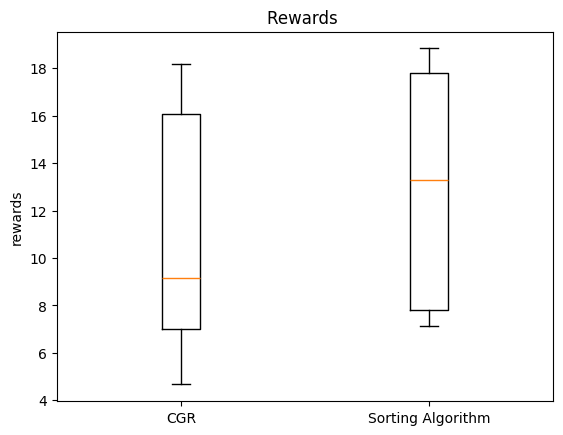

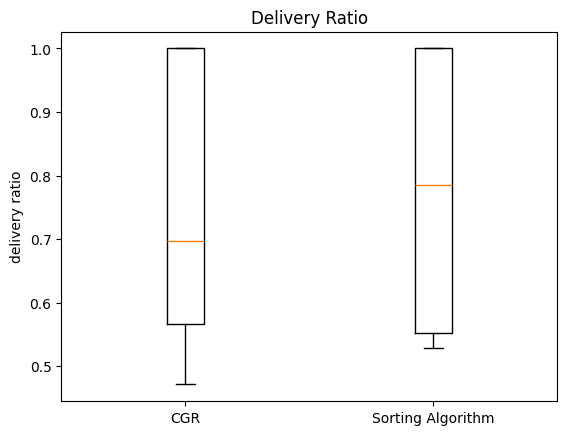

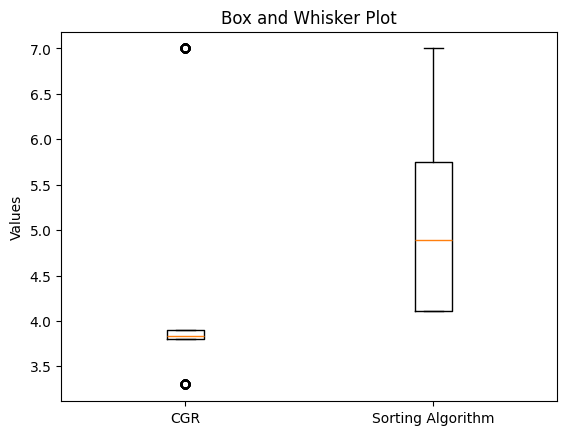

In [7]:
#Next we need to test these baseline algorithms and produce delivery, reward and contact energy efficiency
#graphs
Number_of_Episodes=100
seeds=[50,51,52,53,54]
CGR_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env,b)
          
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts
            vector_index+=1
#Next we must make box plots these results



#Adaptive sorting Algorithm

Sorting_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
Sorting_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
Sorting_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env,b)
            Sorting_reward_vector[vector_index]=total_reward
            
            Sorting_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            print("Delivered Packets")
            print(delivered_packets)
            print("Number of Contacts")
            print(number_of_contacts)
            Sorting_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts
            vector_index+=1
import matplotlib.pyplot as plt
#Reward Plot
print("Sorting Reward")
print(np.mean(Sorting_reward_vector))
print(Sorting_reward_vector)
print(CGR_reward_vector)
print("CGR Reward")
print(np.mean(CGR_reward_vector))
plt.boxplot([CGR_reward_vector, Sorting_reward_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()

#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, Sorting_delivery_ratio_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sorting_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Box and Whisker Plot")
plt.ylabel("Values")
plt.show()